In [1]:
import matplotlib.pyplot as plt
import sys
from scipy.integrate import solve_ivp
from pathlib import Path

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from config.initialize import *
from modules.display import build_profile_dyn, build_profile_stat


# Simulation report
This manuscript is dedicated to compare the simulation result of states for dynamic and static model. The polarization curve was obtained by a static current profile

In [3]:
I_points = [10, 20, 30, 35, 40, 45, 50]

dyn_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass

            states_dyn_log = []
            time_evolutions = []

            for I_LOAD in I_points:
                # --------------- Dynamic Simulation  --------------- #
                operating_inputs["Phi_c_des"] = RHC 
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["Tfc"] = T_des + 273.15
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                x_init = init_x(operating_inputs, parameters)
                model = PEMFC_dyn(parameters,operating_inputs, x_init)
                sol = solve_ivp(model.dxdt, (0, 60), x_init, method='BDF', max_step=1e-1)
                model._recovery(sol)
                # --------------- Log states for dynamic simulation  --------------- #
                states = {} # Log the last state values for each variable => pseudo steady-state values 
                time_evo = {} # Log the time evolution of each variable => check for convergence to steady-state
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                    time_evo[var_name] = model.variables[var_name]
                for key, var_name in enumerate(model.ec_kinetics):
                    states[var_name] = model.ec_kinetics[var_name][-1]
                    time_evo[var_name] = model.ec_kinetics[var_name]

                states_dyn_log.append(states)
                time_evolutions.append(time_evo)
                
            # --------------- Log states profile for both simulations  --------------- #
            states_profile_dyn = {}
            for key, value in enumerate(states_dyn_log[0].keys()):
                states_profile_dyn[value] = [states[value] for states in states_dyn_log]
            dyn_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile_dyn, "time_evolution":time_evolutions}

d:\PEMFC\MFC2024\model\dynamic.py:190: RuntimeWarning: invalid value encountered in log
  Ueq = (E0 - 8.5e-4 * (x['Tccl'] - 298.15) + R * x['Tccl'] / (2 * F) * (np.log(R * x['Tccl'] * x['C_H2_acl'] / Pref) + 0.5 * np.log(R * x['Tccl'] * x['C_O2_ccl'] / Pref)))
d:\PEMFC\MFC2024\model\dynamic.py:718: RuntimeWarning: invalid value encountered in log
  Ueq = (E0 - 8.5e-4 * (x['Tccl'] - 298.15) + R * x['Tccl'] / (2 * F) * (np.log(R * x['Tccl'] * x['C_H2_acl'] / Pref) + 0.5 * np.log(R * x['Tccl'] * x['C_O2_ccl'] / Pref)))
d:\PEMFC\MFC2024\model\kinetic_eq.py:71: RuntimeWarning: invalid value encountered in log
  return (E0 - 8.5e-4 * (Tccl - 298.15) + R * Tccl / (2 * F) * (np.log(R * Tccl * C_H2_acl / Pref) + 0.5 * np.log(R * Tccl * C_O2_ccl / Pref)))
d:\PEMFC\MFC2024\model\kinetic_eq.py:100: RuntimeWarning: invalid value encountered in scalar power
  eta_c = (1 / f_drop * R * Tccl / (alpha_c * F) * np.log((i_fc) / i0_c_ref * (C_O2ref / C_O2_ccl) ** kappa_c) * np.exp(Eact / R * (1 / 353 - 1 

Before comparing the simulation result, the convergency of the state variable in the dynamic model should be verified at a time constant such as 90 seconds.

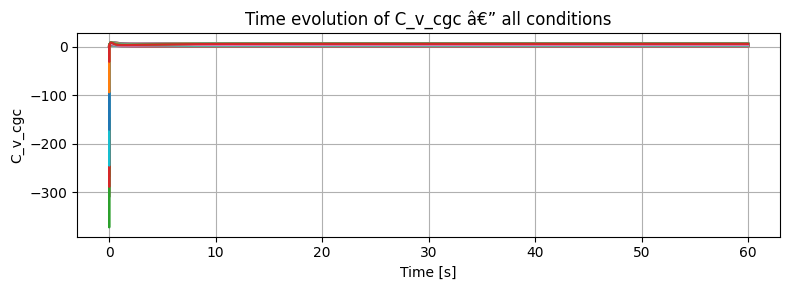

In [4]:
fig, ax = plt.subplots(figsize=(8, 3))

for cond_key, cond_data in dyn_log_all.items():
    for j, I in enumerate(I_points):
        te = cond_data["time_evolution"][j]
        ax.plot(te["t"], te["C_v_cgc"], label=f"{cond_key}, I={I}A")

ax.set_xlabel("Time [s]")
ax.set_ylabel("C_v_cgc")
ax.set_title("Time evolution of C_v_cgc â€” all conditions")
ax.grid(True)
fig.tight_layout()
plt.show()

It's obvious that the vapor concentration in the gas channel stablized at around 40 seconds, which indicated that the net vapor flow from CL to GC is stablized

In [5]:
stat_log_all = {}

for RHC in [0, 0.5]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [50,60,70]:
            if RHC == 0 and P_des != 1.3:
                continue # Skip the condition that not yet carried out on the experimental side
            else:
                pass
            states_stat = []
            for I_LOAD in I_points:
                # --------------- Steady-state Simulation  --------------- #
                Wout_c = 10 + I_LOAD * 2.
                Win_c = 1 + I_LOAD *2.5
                Wout_a = 10 + I_LOAD * 3
                operating_inputs_stat = {'Tfc': T_des + 273.15, 'Phi_a_des': 0, 'Phi_c_des': RHC,
                                                             'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                             'Win_c': Win_c, 'Wout_c': Wout_c, 'Win_a': 0, 'Wout_a': Wout_a}
                model = PEMFC_stat(parameters,operating_inputs_stat)
                sol = model.solve(I_LOAD/parameters['Aact'])
                # --------------- Log states for steady-state simulation  --------------- #
                states_stat.append(sol)
            # --------------- Log states for both simulations  --------------- #
            stat_log_all["RHA"+str(0)+"/RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

## The evolution of the vapor concentration
All unit are converted into $mol/(m^3\cdot s)$

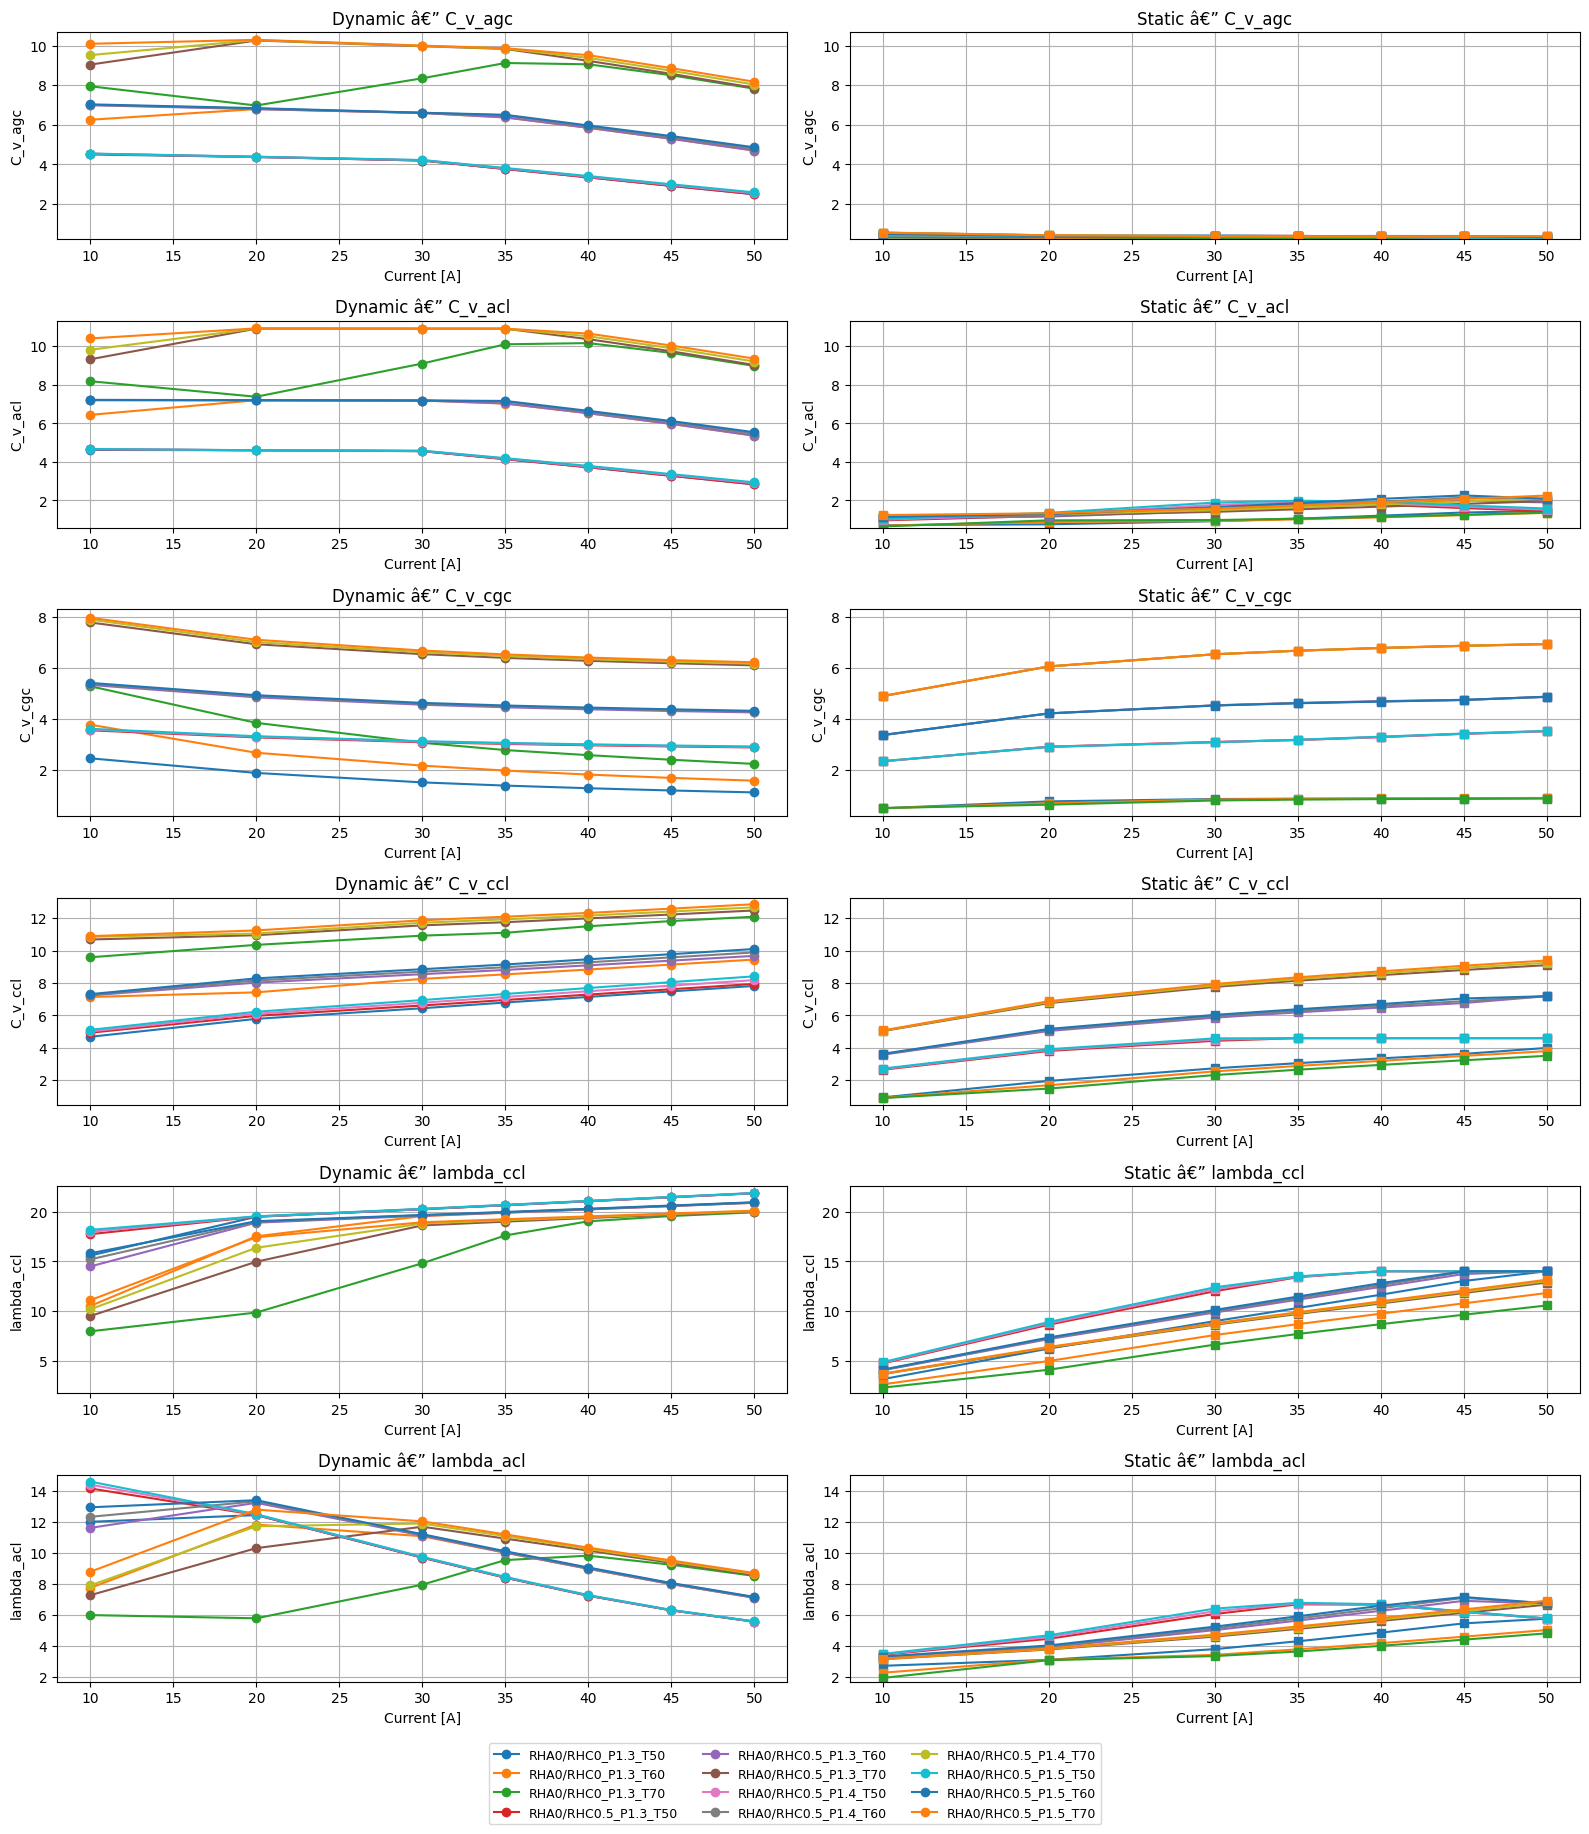

In [6]:
vars = ["C_v_agc", "C_v_acl", "C_v_cgc", "C_v_ccl", "lambda_ccl", "lambda_acl"]

fig, axs = plt.subplots(ncols=2, nrows=6, figsize=(16, 18))

for row, var in enumerate(vars):
    # --- Dynamic (left column) ---
    ax_dyn = axs[row, 0]
    for cond_key in dyn_log_all:
        vals = dyn_log_all[cond_key]["states"][var]
        ax_dyn.plot(I_points, vals, marker='o', label=cond_key)
    ax_dyn.set_xlabel("Current [A]")
    ax_dyn.set_ylabel(var)
    ax_dyn.set_title(f"Dynamic â€” {var}")
    ax_dyn.grid(True)

    # --- Static (right column) ---
    ax_stat = axs[row, 1]
    stat_key = var
    for cond_key in stat_log_all:
        states_list = stat_log_all[cond_key]["states"]
        vals = [s[stat_key] for s in states_list]
        ax_stat.plot(I_points, vals, marker='s', label=cond_key)
    ax_stat.set_xlabel("Current [A]")
    ax_stat.set_ylabel(var)
    ax_stat.set_title(f"Static â€” {var}")
    ax_stat.grid(True)

    # --- Sync y-axis limits for the row ---
    ymin = min(ax_dyn.get_ylim()[0], ax_stat.get_ylim()[0])
    ymax = max(ax_dyn.get_ylim()[1], ax_stat.get_ylim()[1])
    ax_dyn.set_ylim(ymin, ymax)
    ax_stat.set_ylim(ymin, ymax)

# Single legend at the bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


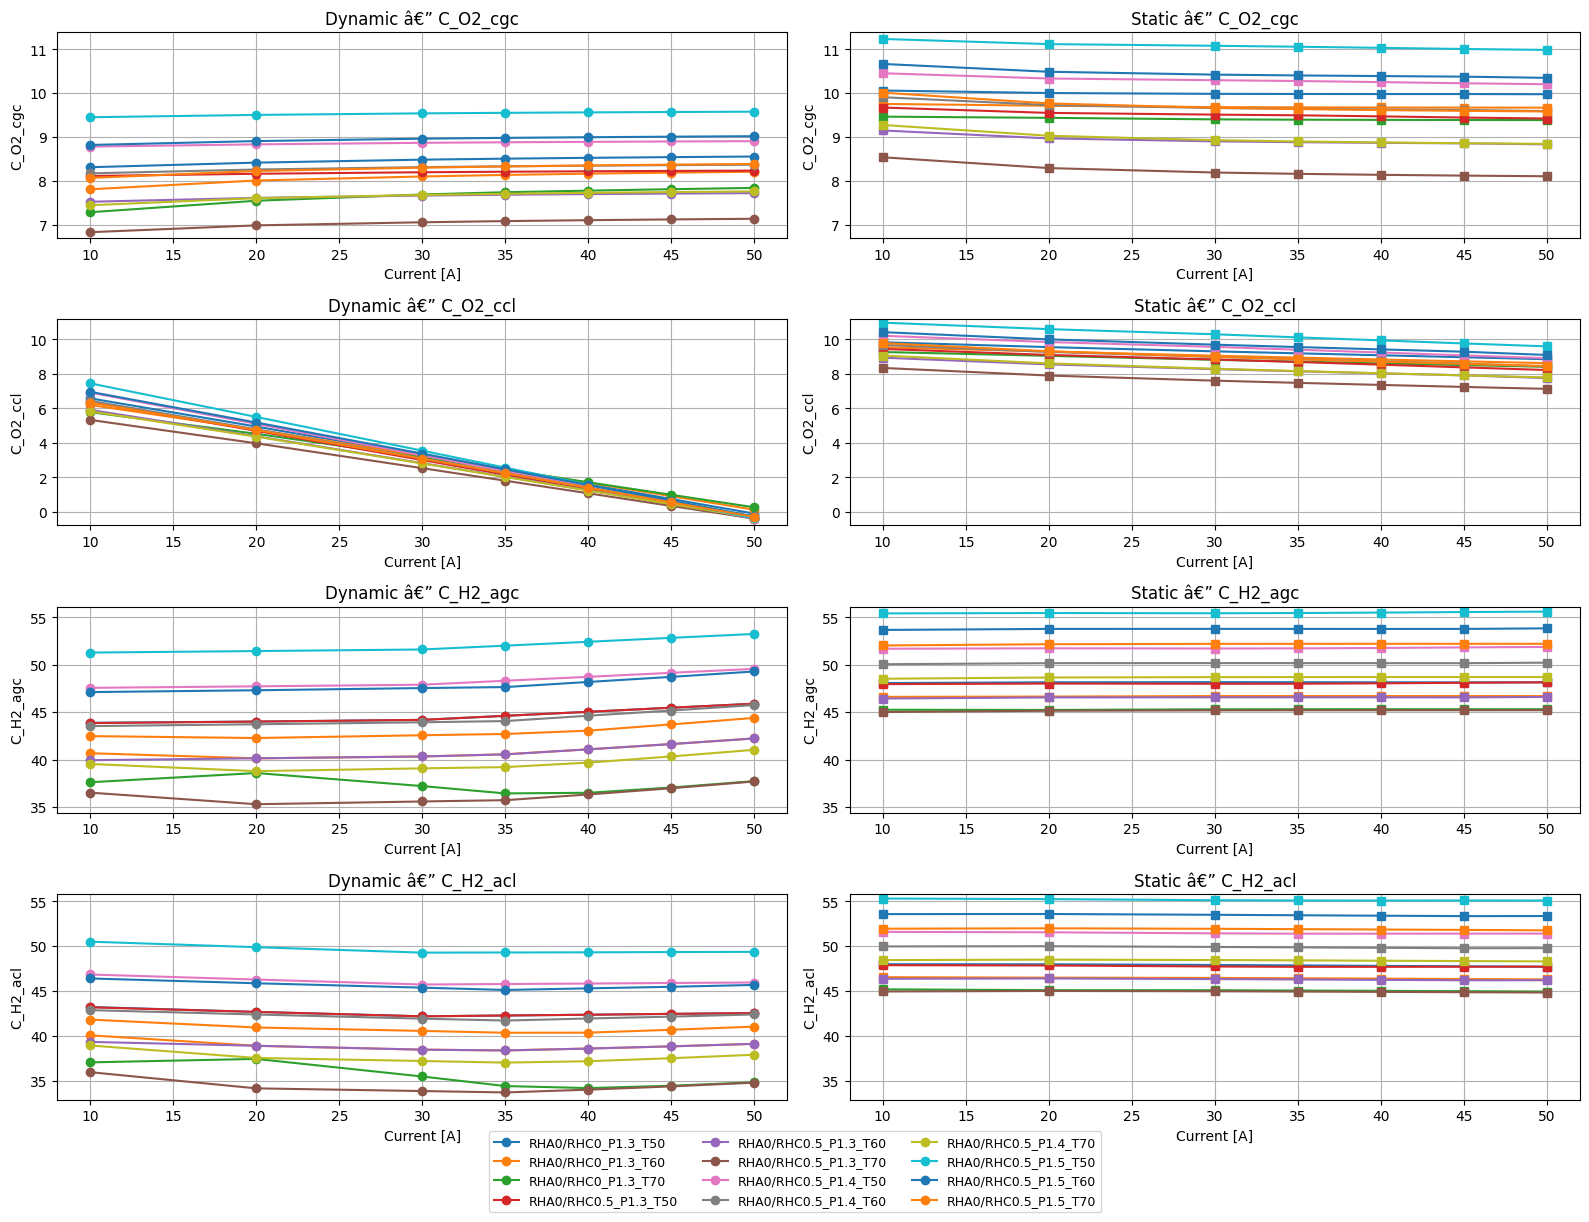

In [7]:
vars = ["C_O2_cgc", "C_O2_ccl", "C_H2_agc", "C_H2_acl"]

fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(16, 12))

for row, var in enumerate(vars):
    # --- Dynamic (left column) ---
    ax_dyn = axs[row, 0]
    for cond_key in dyn_log_all:
        vals = dyn_log_all[cond_key]["states"][var]
        ax_dyn.plot(I_points, vals, marker='o', label=cond_key)
    ax_dyn.set_xlabel("Current [A]")
    ax_dyn.set_ylabel(var)
    ax_dyn.set_title(f"Dynamic â€” {var}")
    ax_dyn.grid(True)

    # --- Static (right column) ---
    ax_stat = axs[row, 1]
    stat_key = var
    for cond_key in stat_log_all:
        states_list = stat_log_all[cond_key]["states"]
        vals = [s[stat_key] for s in states_list]
        ax_stat.plot(I_points, vals, marker='s', label=cond_key)
    ax_stat.set_xlabel("Current [A]")
    ax_stat.set_ylabel(var)
    ax_stat.set_title(f"Static â€” {var}")
    ax_stat.grid(True)

    # --- Sync y-axis limits for the row ---
    ymin = min(ax_dyn.get_ylim()[0], ax_stat.get_ylim()[0])
    ymax = max(ax_dyn.get_ylim()[1], ax_stat.get_ylim()[1])
    ax_dyn.set_ylim(ymin, ymax)
    ax_stat.set_ylim(ymin, ymax)

# Single legend at the bottom
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

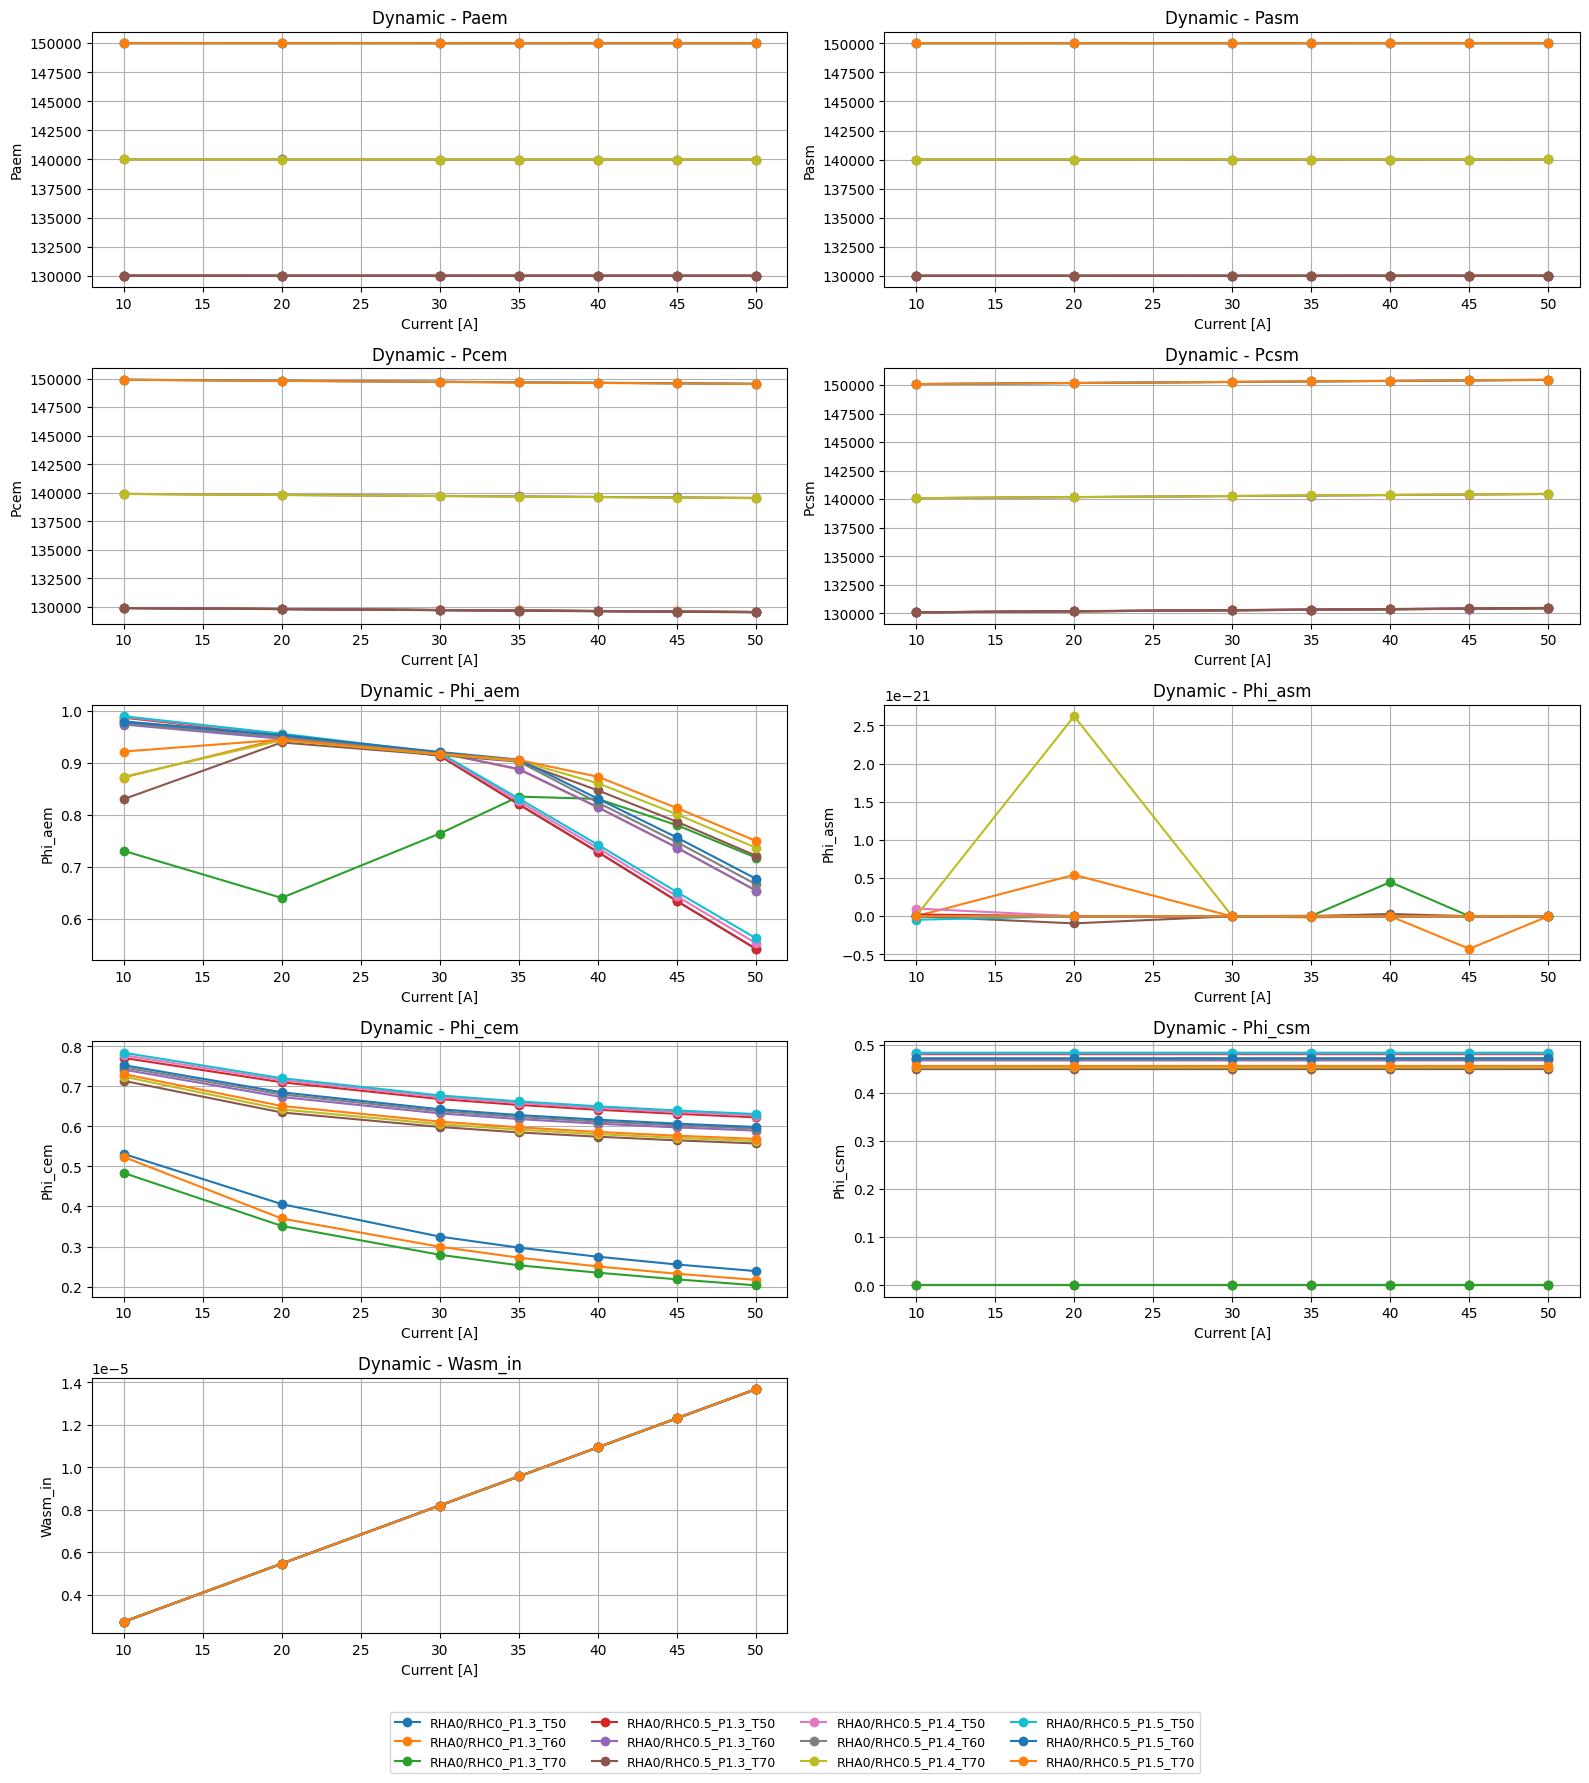

In [8]:
selected_tokens = ("cem", "csm", "aem", "asm")

sample_states = next(iter(dyn_log_all.values()))["states"]
vars = sorted(
    var_name for var_name in sample_states
    if any(token in var_name.lower() for token in selected_tokens)
)

ncols = 2
nrows = int(np.ceil(len(vars) / ncols))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 3.5 * nrows), squeeze=False)

for ax, var in zip(axs.flat, vars):
    for cond_key, cond_data in dyn_log_all.items():
        vals = cond_data["states"][var]
        ax.plot(I_points, vals, marker="o", label=cond_key)
    ax.set_xlabel("Current [A]")
    ax.set_ylabel(var)
    ax.set_title(f"Dynamic - {var}")
    ax.grid(True)

for ax in axs.flat[len(vars):]:
    ax.axis("off")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 1D through-plane profiles at the largest current
The two figures below use `build_profile_dyn` and `build_profile_stat` from `modules.display`.
Both helpers read the line/marker/color from `config.settings.get_plot_properties(cond_key)`, so dynamic and static curves share the same legend mapping and can be compared panel-by-panel.

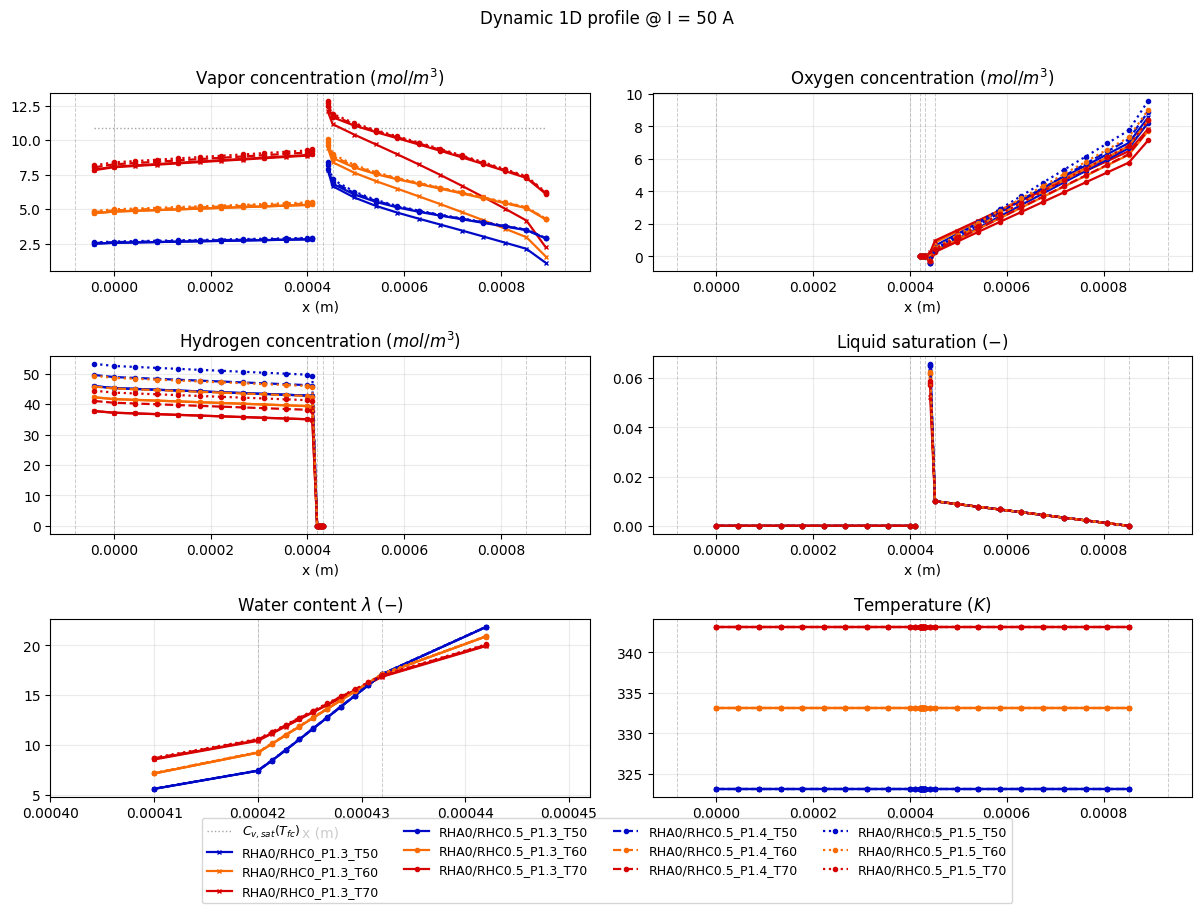

In [9]:
# Dynamic 1D through-plane profile at the highest current point.
I_show = I_points[-1]
fig_dyn, axes_dyn = None, None
for cond_key in dyn_log_all:
    states_at_I = {n: dyn_log_all[cond_key]['states'][n][-1] for n in dyn_log_all[cond_key]['states']}
    fig_dyn, axes_dyn = build_profile_dyn(states_at_I, cond_key=cond_key,
                                          fig=fig_dyn, axes=axes_dyn)
fig_dyn.suptitle(f'Dynamic 1D profile @ I = {I_show} A')
handles, labels = axes_dyn[0].get_legend_handles_labels()
fig_dyn.legend(handles, labels, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig_dyn.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

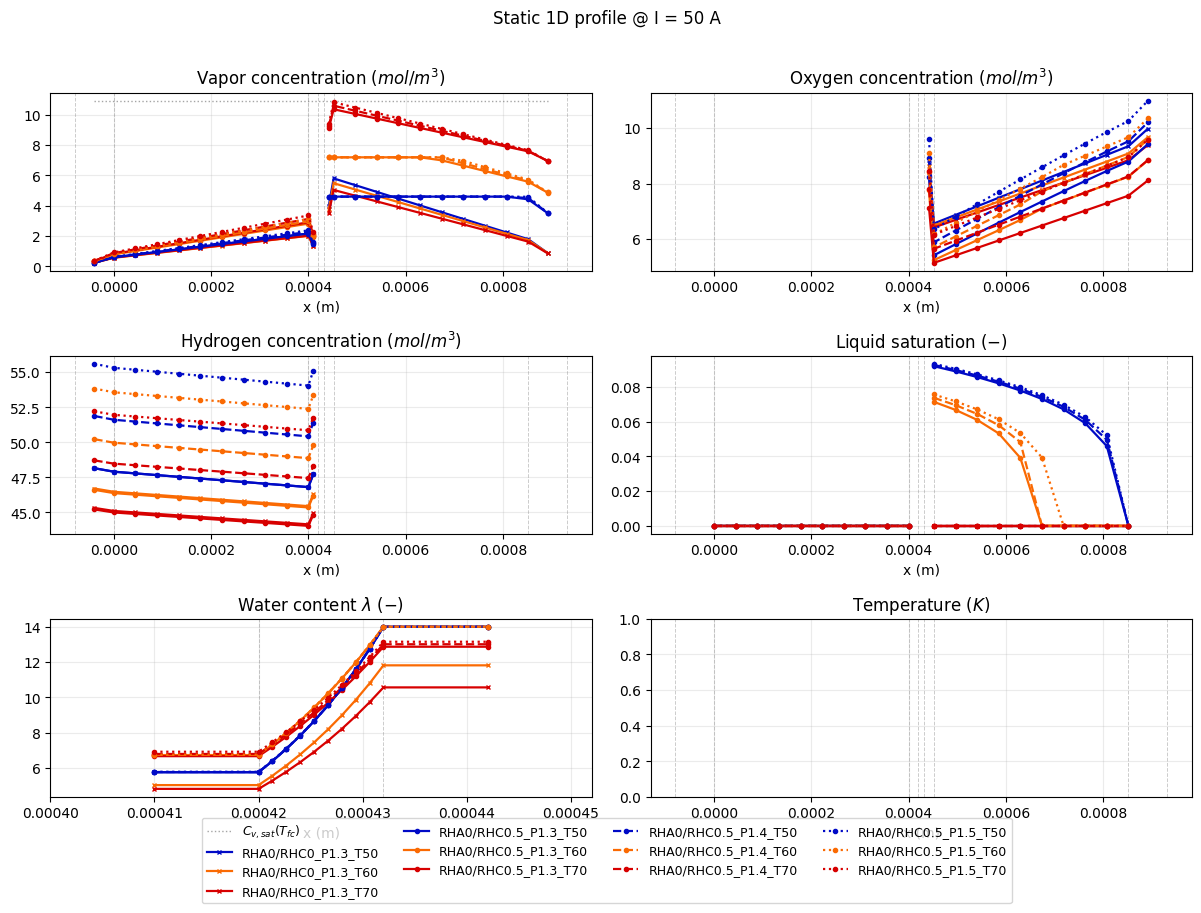

In [10]:
# Static 1D through-plane profile at the highest current point.
I_show = I_points[-1]
j_show = I_points.index(I_show)
fig_stat, axes_stat = None, None
for cond_key in stat_log_all:
    sol = stat_log_all[cond_key]['states'][j_show]
    fig_stat, axes_stat = build_profile_stat(sol, cond_key=cond_key,
                                             fig=fig_stat, axes=axes_stat)
fig_stat.suptitle(f'Static 1D profile @ I = {I_show} A')
handles, labels = axes_stat[0].get_legend_handles_labels()
fig_stat.legend(handles, labels, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig_stat.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()